# Systems of linear equations - continued

## LU decomposition

To solve a system of linear equations, Gaussian elimination requires the fewest arithmetic operations.

When the coefficient matrix $\mathbf{A}$ does not change and only the constant vector $\mathbf{b}$ changes, we can avoid repeating Gaussian elimination on the coefficient matrix. By decomposing the matrix $\mathbf{A}$ we can reach the solution with fewer arithmetic operations. To this end we will look at the LU decomposition!

Any matrix can be written as a product of two matrices:

$$
\mathbf{A}=\mathbf{B}\,\mathbf{C}.
$$

Here, there are infinitely many ways to write the matrices $\mathbf{B}$ and $\mathbf{C}$.

In the LU decomposition we require that the matrix $\mathbf{B}$ is lower triangular and the matrix $\mathbf{C}$ is upper triangular:

$$
\mathbf{A}=\mathbf{L}\,\mathbf{U}.
$$

Each of the matrices $\mathbf{L}$ and $\mathbf{U}$ has $(n+1)\,n/2$ nonzero elements; together that is $n^2+n$ unknowns. The known matrix $\mathbf{A}$ defines $n^2$ values. So to uniquely determine the matrices $\mathbf{L}$ and $\mathbf{U}$ we are missing
$n$ equations. Here we will use the LU decomposition, which obtains the additional equations through the condition $L_{ii}=1$, $i=0, 1,\dots,n-1$.

The system of linear equations:

$$
\mathbf{A}\mathbf{x}=\mathbf{b}
$$

is therefore written using the decomposition of the matrix $\mathbf{A}$:

$$
\mathbf{L}\,\underbrace{\mathbf{U}\,\mathbf{x}}_{\mathbf{y}}=\mathbf{b}.
$$

We now reach the solution of the system $\mathbf{A}\mathbf{x}=\mathbf{b}$ by solving two triangular systems of equations.

First we compute the vector $\mathbf{y}$:

$$
\mathbf{L}\,\mathbf{y}=\mathbf{b}.\qquad \textrm{(forward substitution)}
$$

Once $\mathbf{y}$ is computed, we can determine $\mathbf{x}$ from:

$$
\mathbf{U}\,\mathbf{x}=\mathbf{y}\qquad \textrm{(back substitution)}
$$

.

### LU decomposition of the coefficient matrix $\mathbf{A}$

In what follows we will show that Gaussian elimination actually represents an LU decomposition of the coefficient matrix $\mathbf{A}$. We will rely on symbolic computation, so let's import the `sympy` package:

In [1]:
import sympy as sym # import sympy
sym.init_printing() # for nice display of expressions

Let's begin the demonstration with an example of symbolically written matrices $\mathbf{L}$ and $\mathbf{U}$ of dimension $3\times 3$:

In [2]:
L21, L31, L32 = sym.symbols('L21, L31, L32')
U11, U12, U13, U22, U23, U33 = sym.symbols('U11, U12, U13, U22, U23, U33')
L = sym.Matrix([[  1,   0,  0],
                [L21,   1,  0],
                [L31, L32,  1]])
U = sym.Matrix([[U11, U12, U13],
                [  0, U22, U23],
                [  0,   0, U33]])

The coefficient matrix $\mathbf{A}$ written with the elements of the matrices $\mathbf{L}$ and  $\mathbf{U}$ is therefore:

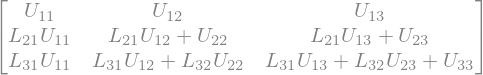

In [3]:
A = L*U
A

Let's now perform Gaussian elimination on the coefficient matrix $\mathbf{A}$.

Using the first row, we perform Gaussian elimination in the first column:

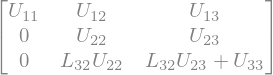

In [4]:
A[1,:] -= L21 * A[0,:]
A[2,:] -= L31 * A[0,:]
A

We continue in the second column:

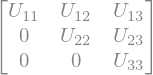

In [5]:
A[2,:] -= L32 * A[1,:]
A

From the elimination above we observe:
1. the matrix $\mathbf{U}$ equals the matrix we obtain if we perform Gaussian elimination on the coefficient matrix $\mathbf{A}$.
* the off-diagonal terms of $\mathbf{L}$ are the factors we used in Gaussian elimination.

### Numerical implementation of the LU decomposition

We will look at the numerical implementation on the system defined as:

In [6]:
import numpy as np

A = np.array([[8, -6, 3],
              [-6, 6, -6],
              [3, -6, 6]], dtype=float)
b = np.array([-14, 36, 6], dtype=float)

Let's perform Gaussian elimination and store the coefficients by which we multiply the pivot row `m` into the matrix `L` at the position with the indices that the eliminated element has in the matrix $\mathbf{A}$.

In [7]:
(v, s) = A.shape # v=number of rows, s=number of columns
U = A.copy()     # prepare the matrix U as a copy of A
L = np.zeros_like(A) # prepare the matrix L of the same dimension as A (values 0)
## elimination
for p, pivot_row in enumerate(U[:-1]):
    for i, row in enumerate(U[p+1:]):
        if pivot_row[p]:
            m = row[p]/pivot_row[p]
            row[p:] = row[p:]-pivot_row[p:]*m
            L[p+1+i, p] = m
    print('Step: {:g}'.format(p))
    print(U)

Korak: 0
[[ 8.    -6.     3.   ]
 [ 0.     1.5   -3.75 ]
 [ 0.    -3.75   4.875]]
Korak: 1
[[ 8.   -6.    3.  ]
 [ 0.    1.5  -3.75]
 [ 0.    0.   -4.5 ]]


In [8]:
L

array([[ 0.   ,  0.   ,  0.   ],
       [-0.75 ,  0.   ,  0.   ],
       [ 0.375, -2.5  ,  0.   ]])

Let's fill in the diagonal of $\mathbf{L}$:

In [9]:
for i in range(v):
    L[i, i] = 1.

In [10]:
L

array([[ 1.   ,  0.   ,  0.   ],
       [-0.75 ,  1.   ,  0.   ],
       [ 0.375, -2.5  ,  1.   ]])

Now let's solve the lower triangular system of equations $\mathbf{L}\,\mathbf{y}=\mathbf{b}$:

In [11]:
## forward substitution
y = np.zeros_like(b)
for i, b_ in enumerate(b):
    y[i] = (b_ - np.dot(L[i, :i], y[:i]))

In [12]:
y

array([-14. ,  25.5,  75. ])

We continue by solving the upper triangular system $\mathbf{U}\,\mathbf{x}=\mathbf{y}$:

In [13]:
U

array([[ 8.  , -6.  ,  3.  ],
       [ 0.  ,  1.5 , -3.75],
       [ 0.  ,  0.  , -4.5 ]])

In [14]:
y

array([-14. ,  25.5,  75. ])

In [15]:
## back substitution
x = np.zeros_like(b)
for i in range(v-1, -1,-1):
    x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
x

array([-14.        , -24.66666667, -16.66666667])

As we noted above, when the constant vector $\mathbf{b}$ changes, repeating Gaussian elimination is not necessary. We only need to perform forward and then back substitution. Let's look at an example:

In [16]:
b = np.array([-1., 6., 7.])
y = np.zeros_like(b)
for i, b_ in enumerate(b):# forward substitution
    y[i] = (b_ - np.dot(L[i, :i], y[:i]))
x = np.zeros_like(b)
for i in range(v-1, -1,-1):# back substitution
    x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
x

array([-4.33333333, -7.88888889, -4.55555556])

In [17]:
A.dot(x)

array([-1.,  6.,  7.])

## Pivoting

Let's look at the following system of equations:

In [ ]:
A = np.array([[0, -6, 6],
              [-6, 6, -6],
              [8, -6, 3]], dtype=float) # try omitting dtype=float here and check the result
b = np.array([6, 36, -14], dtype=float)

If we were to perform Gaussian elimination in the first column of the matrix $\mathbf{A}$:

In [19]:
A[1,:] - A[1,0]/A[0,0] * A[0,:]

C:\Users\janko\AppData\Local\Temp\ipykernel_17316\3999418912.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  A[1,:] - A[1,0]/A[0,0] * A[0,:]
C:\Users\janko\AppData\Local\Temp\ipykernel_17316\3999418912.py:1: RuntimeWarning: invalid value encountered in multiply
  A[1,:] - A[1,0]/A[0,0] * A[0,:]


array([ nan, -inf,  inf])

We notice that we have a problem with division by 0 in the first row. The elementary operations we can perform on the system allow swapping arbitrary rows. We can rearrange the system so that the pivot element is not equal to 0. Even so, it can happen that the pivot element we divide by has a very small value $\varepsilon$. Because this would increase the round-off error, among all the rows we choose for the pivot row the one whose pivot has the largest absolute value.

If during Gaussian elimination we swap rows so that the pivot element is the largest, we call this **row pivoting** or also **partial pivoting**. This makes Gaussian elimination numerically stable.

It can be shown that when solving a system of equations $\mathbf{A}\,\mathbf{x}=\mathbf{b}$ in which the matrix $\mathbf{A}$ is diagonally dominant, row pivoting is not necessary. Solving without pivoting is numerically stable.

A square matrix $\mathbf{A}$ of dimension $n$ is **diagonally dominant** if the absolute value of the diagonal element of each row is greater than the sum of the absolute values of the other elements in the row:

$$
\left|A_{ii}\right|> \sum_{j=1, j\ne i}^n \left|A_{ij}\right|
$$


### Gaussian elimination with partial pivoting

We will look at Gaussian elimination with **partial pivoting**. Without partial pivoting, in the $i$-th elimination step we choose row $i$ as the pivot. With partial pivoting we first check whether the $i$-th diagonal element is, in absolute value, the largest element in column $i$ on or below the diagonal; if not, we swap row $i$ with
the row below it that has the largest element in absolute value in column $i$. With partial pivoting we reduce the influence of the round-off error on the result.

If we were to perform **full pivoting**, in addition to swapping rows we would also use swapping the order of the variables (column swapping). Full pivoting improves stability, but it is rarely used and we will not address it here.

The algorithm for Gaussian elimination with partial pivoting is therefore:

In [20]:
def gaussian_elimination_pivoting(A, b, show_steps=False):
    """ Returns the Gaussian elimination of the augmented coefficient matrix,
    using partial pivoting.

    :param A: coefficient matrix
    :param b: constant vector
    :param show_steps: whether to print the individual steps
    :return Ab: trapezoidal augmented coefficient matrix
    """
    Ab = np.column_stack((A, b))
    for p in range(len(Ab)-1):
        p_max = np.argmax(np.abs(Ab[p:,p]))+p
        if p != p_max:
            Ab[[p], :], Ab[[p_max], :] = Ab[[p_max], :], Ab[[p], :]
        pivot_row = Ab[p, :]
        for row in Ab[p + 1:]:
            if pivot_row[p]:
                row[p:] -= pivot_row[p:] * row[p] / pivot_row[p]
        if show_steps:
            print('Step: {:g}'.format(p))
            print('Pivot row:', pivot_row)
            print(Ab)
    return Ab

In [21]:
A

array([[ 0., -6.,  6.],
       [-6.,  6., -6.],
       [ 8., -6.,  3.]])

In [22]:
Ab = gaussian_elimination_pivoting(A, b, show_steps=True)

Korak: 0
Pivot vrsta: [  8.  -6.   3. -14.]
[[  8.    -6.     3.   -14.  ]
 [  0.     1.5   -3.75  25.5 ]
 [  0.    -6.     6.     6.  ]]
Korak: 1
Pivot vrsta: [ 0. -6.  6.  6.]
[[  8.    -6.     3.   -14.  ]
 [  0.    -6.     6.     6.  ]
 [  0.     0.    -2.25  27.  ]]


### LU decomposition with partial pivoting

Similarly to Gaussian elimination, we can also extend the LU decomposition with partial pivoting. Solving thus becomes numerically **stable**. In doing so we must store the information about the row swaps, which we then pass to the function for solving the corresponding triangular systems.

In [23]:
def LU_decomposition_pivoting(A, show_steps=False):
    """ Returns the LU decomposition matrix and the vector of swapped rows (pivoting),
    using partial pivoting.

    :param A: coefficient matrix
    :param show_steps: print the individual steps
    :return LU: LU matrix
    :return pivoting: vector of row swaps (important when finding the solution)
    """
    LU = A.copy()
    pivoting = np.arange(len(A))
    for p in range(len(LU)-1):
        p_max = np.argmax(np.abs(LU[p:,p]))+p
        if p != p_max:
            LU[[p], :], LU[[p_max], :] = LU[[p_max], :], LU[[p], :]
            pivoting[p], pivoting[p_max] = pivoting[p_max], pivoting[p]
        pivot_row = LU[p, :]
        for row in LU[p + 1:]:
            if pivot_row[p]:
                m = row[p] / pivot_row[p]
                row[p:] -= pivot_row[p:] * m
                row[p] = m
            else:
                raise Exception('Division by 0.')
        if show_steps:
            print('Step: {:g}'.format(p))
            print('Pivot row:', pivot_row)
            print(LU)
    return LU, pivoting

Let's look at an example:

In [24]:
A = np.array([[0, -6, 6],
              [-6, 6, -6],
              [8, -6, 3]], dtype=float)
b = np.array([-14, 36, 6], dtype=float)

In [25]:
lu, piv = LU_decomposition_pivoting(A, show_steps=True)

Korak: 0
Pivot vrsta: [ 8. -6.  3.]
[[ 8.   -6.    3.  ]
 [-0.75  1.5  -3.75]
 [ 0.   -6.    6.  ]]
Korak: 1
Pivot vrsta: [ 0. -6.  6.]
[[ 8.   -6.    3.  ]
 [ 0.   -6.    6.  ]
 [-0.75 -0.25 -2.25]]


In the example above we used a compact way of storing the triangular matrices $\mathbf{L}$ and $\mathbf{U}$; each is in fact defined by 6 elements, and for the matrix $\mathbf{L}$ we know that the diagonal elements equal 1. The matrix `lu` thus contains $3\times3=9$ elements:

In [26]:
lu

array([[ 8.  , -6.  ,  3.  ],
       [ 0.  , -6.  ,  6.  ],
       [-0.75, -0.25, -2.25]])

On the diagonal and above the diagonal are the values of the upper triangular matrix $\mathbf{U}$, while below the diagonal are the subdiagonal elements of the matrix $\mathbf{L}$. When computing the solution we will take into account that the diagonal values of $\mathbf{L}$ equal 1.

The numeric list `piv` tells us how the rows were swapped, which must be taken into account when computing the solution:

In [27]:
piv

array([2, 0, 1])

Let's now also determine the solution (the code for computing the solution is in the module `tools.py`)

In [28]:
from modules import tools

In [29]:
r = tools.LU_solve_pivoting(lu, b, piv)
r

array([ -3.66666667, -14.11111111, -16.44444444])

Checking the solution:

In [30]:
A@r

array([-14.,  36.,   6.])

## The ``SciPy`` module

The ``SciPy`` module is built on the ``numpy`` module and contains many different high-level programs/modules/functions. The theoretical background of the modules is of course various numerical algorithms; we will get to know some of them within this textbook as well. A good source for these numerical algorithms in connection with `SciPy` is the [documentation](https://docs.scipy.org/doc/scipy/reference/tutorial/). For an excellent introduction to SciPy you can watch the [YouTube video: SciPy Tutorial (2022): For Physicists, Engineers, and Mathematicians](https://www.youtube.com/watch?v=jmX4FOUEfgU).

A brief overview of the module hierarchy:

* Linear algebra ([scipy.linalg](http://docs.scipy.org/doc/scipy/reference/linalg.html))
* Integration ([scipy.integrate](http://docs.scipy.org/doc/scipy/reference/integrate.html))
* Optimization ([scipy.optimize](http://docs.scipy.org/doc/scipy/reference/optimize.html))
* Interpolation ([scipy.interpolate](http://docs.scipy.org/doc/scipy/reference/interpolate.html))
* Fourier transform ([scipy.fftpack](http://docs.scipy.org/doc/scipy/reference/fftpack.html))

* Eigenvalue problem (sparse matrices) ([scipy.sparse](http://docs.scipy.org/doc/scipy/reference/sparse.html))
* Statistics ([scipy.stats](http://docs.scipy.org/doc/scipy/reference/stats.html))
* Signal processing ([scipy.signal](http://docs.scipy.org/doc/scipy/reference/signal.html))
* Special functions ([scipy.special](http://docs.scipy.org/doc/scipy/reference/special.html))
* Multidimensional image processing ([scipy.ndimage](http://docs.scipy.org/doc/scipy/reference/ndimage.html))
* File handling ([scipy.io](http://docs.scipy.org/doc/scipy/reference/io.html))

In the following lectures we will look at some of the submodules in more detail.

Let's look at how the *LU decomposition* is implemented within ``SciPy``:

In [31]:
from scipy.linalg import lu_factor, lu_solve

The function ``scipy.linalg.lu_factor`` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu_factor.html)):

```python
lu_factor(a, overwrite_a=False, check_finite=True)
```

requires the input of a coefficient matrix (or a list of coefficient matrices) `a`; `overwrite_a`, if `True`, overwrites the value of `a` with the result of the decomposition (this can be important to save memory and increase speed). The function `lu_factor` returns a tuple `(lu, piv)`:


* `lu` - the $\mathbf{L}$ \ $\mathbf{U}$ matrix (a matrix of the same dimension as `a`, but below the diagonal it contains the elements of $\mathbf{L}$, while the remaining elements define $\mathbf{U}$; the diagonal elements of $\mathbf{L}$ have values 1.
* `piv` - the pivot indices, representing a permutation matrix `P`: row  `i` of the matrix `a` was swapped with row `piv[i]` (at each step the previous state is taken into account, slightly different logic than in our function `LU_decomposition_pivoting`).

``lu_factor`` is used together with the function ``scipy.linalg.lu_solve`` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu_solve.html)), which gives us the solution of the system:

```python
lu_solve(lu_and_piv, b, trans=0, overwrite_b=False, check_finite=True)
```

`lu_and_piv` is the tuple of the result `(lu, piv)` from ``lu_factor``, `b` is the constant vector (or a list of vectors). The other parameters are optional.

Let's look at how to use it:

In [32]:
A = np.array([[0, -6, 6],
              [-6, 6, -6],
              [8, -6, 3]], dtype=float)
b = np.array([-14, 36, 6], dtype=float)

In [33]:
lu, piv = lu_factor(A)

In [34]:
lu

array([[ 8.  , -6.  ,  3.  ],
       [ 0.  , -6.  ,  6.  ],
       [-0.75, -0.25, -2.25]])

In [35]:
piv

array([2, 2, 2], dtype=int32)

Let's obtain the solution:

In [36]:
r = lu_solve((lu, piv), b)
r

array([ -3.66666667, -14.11111111, -16.44444444])

Let's check the validity of the solution:

In [37]:
A@r

array([-14.,  36.,   6.])

## Computing the inverse matrix

The inverse matrix of a square matrix $\textbf{A}$ of order $n\times n$ is denoted by $\textbf{A}^{-1}$. It is a matrix of order $n\times n$,  such that

$$\mathbf{A}\,\mathbf{A}^{-1} = \mathbf{A}^{-1}\,\mathbf{A} = \mathbf{I},$$

where $\mathbf{I}$ is the identity matrix.

The most efficient way to compute the inverse of a matrix $\mathbf{A}$ is to solve the matrix equation:

$$\mathbf{A}\,\mathbf{X}=\mathbf{I}.$$

The matrix $\mathbf{X}$ is the inverse of the matrix $\mathbf{A}$: $\mathbf{A}^{-1}=\mathbf{X}$.

Computing the inverse matrix is therefore equal to solving $n$ systems of $n$ linear equations:

$$\mathbf{A}\,\mathbf{x}_i=\mathbf{b}_i,\qquad i=0,1,2,\dots,n-1,$$

where $\mathbf{b}_i$ is the $i$-th column of the matrix $\mathbf{B}=\mathbf{I}$.

*Computational cost:* we perform the LU decomposition on the matrix $\mathbf{A}$ (computational cost of order $n^3$) and then
find the solution for each $\mathbf{x}_i$ ($2\,n^2$ arithmetic operations for each $i$). The total computational cost is therefore still of order $n^3$. (If we were to perform Gaussian elimination $n$ times, the cost would be of order $n^4$.)

In [38]:
lu_piv = lu_factor(A)
lu_piv

(array([[ 8.  , -6.  ,  3.  ],
        [ 0.  , -6.  ,  6.  ],
        [-0.75, -0.25, -2.25]]),
 array([2, 2, 2], dtype=int32))

Here the point of the LU decomposition now becomes apparent; we compute the decomposition only once and then, for each constant vector, find the solution by solving two triangular systems. If we were to solve the systems by Gaussian elimination, we would need $(n^3+n^2)\,n$ arithmetic operations.

Let's compute the inverse of the matrix $\textbf{A}$. First we prepare the identity matrix using `np.identity()`:

In [39]:
np.identity(len(A))

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

Then we solve the system of equations for each column of the identity matrix:

In [40]:
A_inv = np.zeros_like(A) # zeros_like returns a matrix of the shape and type of matrix A with values 0
for b, a_inv in zip(np.identity(len(A)), A_inv):
    a_inv[:] = lu_solve(lu_piv, b)
A_inv = A_inv.T

The solution is therefore:

In [41]:
A_inv

array([[-1.66666667e-01, -1.66666667e-01,  1.38777878e-17],
       [-2.77777778e-01, -4.44444444e-01, -3.33333333e-01],
       [-1.11111111e-01, -4.44444444e-01, -3.33333333e-01]])

Let's check the solution:

In [42]:
A@A_inv

array([[ 1.00000000e+00,  0.00000000e+00,  1.11022302e-16],
       [ 0.00000000e+00,  1.00000000e+00, -1.11022302e-16],
       [ 5.55111512e-17,  0.00000000e+00,  1.00000000e+00]])

Solution using NumPy:

In [43]:
#%%timeit
np.linalg.inv(A)

array([[-1.66666667e-01, -1.66666667e-01,  1.38777878e-17],
       [-2.77777778e-01, -4.44444444e-01, -3.33333333e-01],
       [-1.11111111e-01, -4.44444444e-01, -3.33333333e-01]])

With appropriate use of functions from the `SciPy` module we can reach the solution even faster. Into the function ``lu_solve`` we can insert a vector $\mathbf{b}$ or a matrix $\mathbf{B}$, each column $i$ of which represents a new constant vector $\mathbf{b}_i$.

In [44]:
#%%timeit
lu_solve(lu_piv, np.identity(len(A)))

array([[-1.66666667e-01, -1.66666667e-01,  1.38777878e-17],
       [-2.77777778e-01, -4.44444444e-01, -3.33333333e-01],
       [-1.11111111e-01, -4.44444444e-01, -3.33333333e-01]])

## Solving overdetermined systems

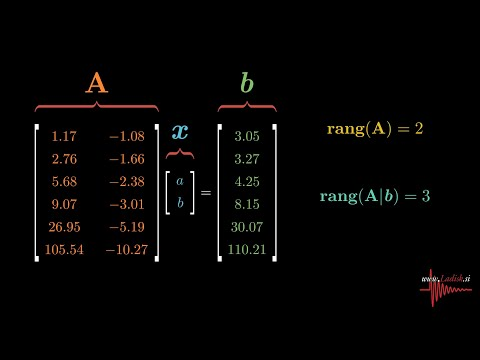

In [45]:
from IPython.display import YouTubeVideo
YouTubeVideo('N6upu99LbfQ', width=800, height=300)

When we solve a system of $m$ linear equations with $n$ unknowns and $m>n$ holds and the rank of the augmented matrix $[\mathbf{A}\,|\,\mathbf{b}]$ equals $n+1$, we have an overdetermined (inconsistent) system.

An overdetermined (also **inconsistent system**):

$$\mathbf{A}\,\mathbf{x}=\mathbf{b},$$

has no solution. However, we can find the best approximate solution using the **least-squares** method.

The sum of squares of the residuals is defined by the dot product:

$$\left\lVert r\right\rVert ^2=(\mathbf{A}\,\mathbf{x}-\mathbf{b})^T\,(\mathbf{A}\,\mathbf{x}-\mathbf{b})$$

which we reshape into:

$$\left\lVert r\right\rVert^2=\mathbf{x}^T\mathbf{A}^T\mathbf{A}\mathbf{x}-2\mathbf{b}^T\mathbf{A}\mathbf{x}+\mathbf{b}^T\mathbf{b},
$$

where we have used the fact that, due to the scalar value, $\mathbf{b}^T\mathbf{A}\mathbf{x}=(\mathbf{b}^T(\mathbf{A}\mathbf{x}))^T=(\mathbf{A}\mathbf{x})^T\mathbf{b}$.

The solution of the equation, the gradient of the sum of squares, determines its minimum:

$$
\nabla_x\,\left\lVert r\right\rVert^2=2\mathbf{A}^T\mathbf{A}\,\mathbf{x}-2\mathbf{A}^T\,\mathbf{b}=0
$$

Thus, from the normal equation:

$$
\mathbf{A}^T\mathbf{A}\,\mathbf{x}=\mathbf{A}^T\,\mathbf{b}
$$

we determine the best approximate solution:

$$
\mathbf{x}=\left(\mathbf{A}^T\mathbf{A}\right)^{-1}\mathbf{A}^T\,\mathbf{b}.
$$

By introducing the **pseudo-inverse matrix**:

$$
\mathbf{A}^+=\left(\mathbf{A}^T\mathbf{A}\right)^{-1}\mathbf{A}^T
$$

of the matrix $\mathbf{A}$, the solution of the overdetermined system is written:

$$
\mathbf{x}=\mathbf{A}^+\,\mathbf{b}.
$$

The procedure presented above is relatively simple, but it is numerically demanding and in some cases can be ill-conditioned; in practice it is recommended that the pseudo-inverse matrix be computed using the functions:

* `numpy.linalg.pinv` from the `numpy` module ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.pinv.html)),
* The functions `pinv`, `pinv2` or `pinvh` from the `scipy.linalg` module (the choice depends on the problem being addressed; see the [documentation](https://docs.scipy.org/doc/scipy/reference/linalg.html)),

which are based on better numerical methods.

Example of a system with a unique solution:

In [46]:
## number of equations equal to the number of unknowns
A = np.array([[1., 2],
              [2, 3]])
b = np.array([5., 8])
np.linalg.solve(A, b)

array([1., 2.])

Now let's make an overdetermined system (the function `numpy.vstack` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.vstack.html)) stacks lists by columns, `numpy.random.seed` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.seed.html)) resets the random number generator to the seed value `seed`, while `numpy.random.normal` ([documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.normal.html)) generates a normally distributed list of length `size` and standard deviation `scale`):

In [47]:
vA = np.vstack([A,A,A])
np.random.seed(seed=0)
vA += np.random.normal(scale=0.01, size=vA.shape) # corrupt the solution -> the system is overdetermined
vA # coefficient matrix

array([[1.01764052, 2.00400157],
       [2.00978738, 3.02240893],
       [1.01867558, 1.99022722],
       [2.00950088, 2.99848643],
       [0.99896781, 2.00410599],
       [2.00144044, 3.01454274]])

In [48]:
vb = np.hstack([b,b,b])
vb += np.random.normal(scale=0.01, size=vb.shape)
vb # constant vector

array([5.00761038, 8.00121675, 5.00443863, 8.00333674, 5.01494079,
       7.99794842])

Now let's solve the overdetermined system:

In [49]:
Ap = np.linalg.pinv(vA)
Ap.dot(vb)

array([0.94512271, 2.02675939])

We see that the overdetermined system with random values (simulation of measurement noise) gives a similar result to the solution without noise. If we were to increase the noise level, the deviation from the unique solution would increase.

We can also determine the pseudo-inverse matrix ourselves and check the difference with the built-in function:

In [50]:
#%%timeit # check the speed!
Ap2 = np.linalg.inv(vA.T@vA) @ vA.T

Ap2 - Ap

array([[-8.88178420e-16,  2.77555756e-15,  3.33066907e-16,
         3.33066907e-15, -1.11022302e-15,  2.99760217e-15],
       [ 1.22124533e-15, -6.10622664e-16,  4.44089210e-16,
        -6.66133815e-16,  1.11022302e-15, -1.27675648e-15]])

## Iterative methods

We often encounter large systems of linear equations whose coefficient matrix has few nonzero elements (such matrices are called **sparse**).

Iterative methods perform very well when solving such systems of linear equations; their advantages compared to direct methods are:

* arithmetic operations are performed only on the nonzero elements (despite the iterative solving, there can be fewer of them)
* the required memory space can be incomparably smaller.

### Gauss-Seidel method

In what follows we will look at the idea of the *Gauss-Seidel* iterative method. First we write the system of equations $\mathbf{A}\,\mathbf{x}=\mathbf{b}$ as:

$$
\sum_{j=0}^{n-1} A_{ij}x_j=b_i\qquad{}i=0,1,\dots,n-1.
$$

Suppose we are in step $k-1$ of the iterative method and the approximations $x_{j}^{(k-1)}$ ($j=0,1,\dots, n-1$) are known. From the sum above we isolate the term $i$:

$$
A_{ii}\,x_{i}^{(k-1)} +\sum_{j=0, j\ne i}^{n-1} A_{ij}x_{j}^{(k-1)}=b_i\qquad{}i=0,1,\dots,n-1.
$$

Since the approximations $x_{j}^{(k-1)}$ do not exactly satisfy the linear problem, we can determine a new approximation $x_{i}^{(k)}$ from the equation above:

$$
x_{i}^{(k)} =\frac{1}{A_{ii}}\left(b_i-\sum_{j=0}^{i-1} A_{ij}x_{j}^{(k)}-\sum_{j=i+1}^{n-1} A_{ij}x_{j}^{(k-1)}\right)
$$

We have split the sum into two parts and, for computing the $i$-th term, taken into account the terms with index smaller than $i$ already determined in the $k$-th iteration.

We stop the iterative approach when we reach the desired accuracy of the solution $\epsilon$:

$$
||x_{i}^{(k)}-x_{i}^{(k-1)}||<\epsilon
$$

### Example

In [51]:
A = np.array([[8, -1, 1],
              [-1, 6, -1],
              [0, -1, 6]], dtype=float)
b = np.array([-14, 36, 6], dtype=float)

Initial approximation:

In [52]:
x = np.zeros(len(A))
x

array([0., 0., 0.])

Let's prepare the matrix $\mathbf{A}$ without the diagonal elements (Why? Try to answer below, once we have performed the iterations.)

In [53]:
K = A.copy() # make a copy so that we don't overwrite the data
np.fill_diagonal(K, np.zeros(3)) # change only the diagonal elements

In [54]:
K

array([[ 0., -1.,  1.],
       [-1.,  0., -1.],
       [ 0., -1.,  0.]])

Let's perform the iterations:

$$
x_{i}^{(k)} =\frac{1}{A_{ii}}\left(b_i-\sum_{j=0}^{i-1} A_{ij}x_{j}^{(k)}-\sum_{j=i+1}^{n-1} A_{ij}x_{j}^{(k-1)}\right)
$$

(Since we will write the values into `x` right away, there is no need to split the sum into two parts)

In [55]:
for k in range(3):
    xk_1 = x.copy()
    print(5*'-' + f'iteration {k}' + 5*'-')
    for i in range(len(A)): # observe what happens when you run this cell several times!
        x[i] = (b[i]-K[i,:].dot(x))/A[i,i]
        print(f'Approximation for element {i}', x)
    e = np.linalg.norm(x-xk_1)
    print(f'Norm {e}')

-----iteracja 0-----
Približek za element 0 [-1.75  0.    0.  ]
Približek za element 1 [-1.75        5.70833333  0.        ]
Približek za element 2 [-1.75        5.70833333  1.95138889]
Norma 6.281360365408393
-----iteracja 1-----
Približek za element 0 [-1.28038194  5.70833333  1.95138889]
Približek za element 1 [-1.28038194  6.11183449  1.95138889]
Približek za element 2 [-1.28038194  6.11183449  2.01863908]
Norma 0.6227976321231091
-----iteracja 2-----
Približek za element 0 [-1.23835057  6.11183449  2.01863908]
Približek za element 1 [-1.23835057  6.13004808  2.01863908]
Približek za element 2 [-1.23835057  6.13004808  2.02167468]
Norma 0.04590845211691733


Let's check the solution

In [56]:
A@x

array([-14.01517799,  35.9969644 ,   6.        ])

The method works well if the matrix is diagonally dominant (there are, however, methods that work even when the matrix is not diagonally dominant; see e.g.: J. Petrišič, Reševanje enačb, 1996, p. 149: Conjugate gradient method).

---

# Exercise questions

---

## LU decomposition

**Question 1:** The force and moment equilibrium equations for the beam in the figure are written:

<img src="fig/vaje/nosilec.PNG" style="width:550px">

Determine the support reactions for five different angles $\varphi$ from the given list, performing the decomposition of the coefficient matrix only once. Print the solution each time using the ``print`` function.

$$
\begin{align}
\text{direction }x &:\quad  A_x = F\,\cos(\varphi)\\
\text{direction }y &:\quad A_y + B = F\,\sin(\varphi)\\
\text{moment about }A&:\quad Bl = Fa\,\sin(\varphi)
\end{align}
$$

In [ ]:
# Data
L = 1.5 # m
a = 0.55 # m
F = 85 # N
phi_list = [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2]

----------

## Computing the inverse of a matrix

**Question 2:** use the LU decomposition and, following the procedure described above, determine the inverse of the matrix $\mathbf{A}$ from the previous problem.

-------------

## Solving overdetermined systems - pseudo-inverse

**Question 3:** Determine the best-fit line that describes $n$ given points $(X, Y)$ with minimal squared error. Find the parameters $k$ and $n$ of the best-fit line $y = kx+n$ by solving the system of linear equations:

$$\mathbf{[X, 1]}_{~n\times 2}~\mathbf{x} = \mathbf{[Y]}$$

where the first column of the coefficient matrix contains the $X$ coordinates of the given points, while the second column contains all ones. The right-hand side vector equals the vector $Y$ of coordinates of the points considered.

On the same figure, plot the set of points $(X, Y)$ and the resulting best-fit line.

In [ ]:
# Data
X = np.linspace(1, 10, 100)
Y = 0.7*X - 15.5 + np.random.randn(len(X))
plt.plot(X, Y, 'b.')

-------------

## Iterative methods for solving systems of linear equations


### Gauss-Seidel


$$x_i =\frac{1}{A_{ii}}\left(b_i-\sum_{j=0, j\ne i}^n A_{ij}x_j\right)\qquad{}i=0,1,\dots,n-1$$

**Question 4:** Using the iterative Gauss-Seidel method, solve the given system of equations.

Compare the result with Gaussian elimination. Observe the influence of the number of iterations on the accuracy of the solution.

In [ ]:
# Data
A = np.array([[-1, 2, 0, 0, 0, 0],
             [-1, 3, 1, 0, 0, 0],
             [0, -1, 4, 1, 0, 0],
             [0, 0, -2, 5, 0, 0],
             [0, 0, 0, 0, 5, 3],
             [0, 0, 0, 0, 1, -3]], dtype=float)

b = np.array([0, 18, 0, 12, 3, 5], dtype=float)